In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import time
import matplotlib
import sys
import pandas as pd

sys.path.append('../')
from carpet_reconstruction import GetCarpetSignal, VEM, get_rho, NKG, num_sort, get_xy_fits

from matplotlib.backends.backend_pdf import PdfPages
from skimage.feature import peak_local_max
from scipy.optimize import minimize
from scipy.optimize import curve_fit
from scipy.special import gamma

In [2]:
# matplotlib.use('pdf') #Чтобы не убить оперативку
plt.rcParams['figure.dpi'] = 400
# plt.style.use('fivethirtyeight')

In [3]:
path = '../Data/photon_data/'

filenames = [path + filename for filename in os.listdir(path)]
filenames.sort(key=num_sort)

In [4]:
Ne = []
Ne_true = []
E = []

for filename in filenames:

    print(filename)
    
    file = uproot.open(filename)

    names = np.array(file.keys())
    times = names[:len(names) // 3]
    cover_hists = names[len(names) // 3::2]

    cover_signals = np.zeros((len(cover_hists), 20, 20))

    for i, hist in enumerate(cover_hists):
        cov_hist = np.copy(np.flip(file[hist].values().T, 0))
        cover_signals[i] = VEM(GetCarpetSignal(cov_hist))
    
    time_array = np.zeros((len(times), 4))
    
    for i, t in enumerate(times):
        time_array[i] = file[t]['t_ns'].array(library='np')[1:5]

    for i in range(len(cover_signals)):

        sig = cover_signals[i]
        times = time_array[i]
        theta = float(cover_hists[i].split('_')[1])

        if ((theta < 30) and (np.all(times)) and (np.count_nonzero(sig) > 50)):

            r, rho = get_rho(sig, times)
        
            try:
                popt, pcov = curve_fit(NKG, r, rho, bounds=([0.4, 10**4], [1.8, 10**8]))
                #axs[0].plot(r, NKG(r, *popt), '-ro', linewidth = 2, markersize=3, label='NKG fit: s=%5.3f, Ne=%5.3f' % tuple(popt))
                Ne_local = popt[1]
                Ne_true_local = float(cover_hists[i].split('_')[-1].split(';')[0])
                E_local = float(cover_hists[i].split('_')[0])

                Ne.append(Ne_local)
                Ne_true.append(Ne_true_local)
                E.append(E_local)
        
            except RuntimeError:
                ...
                # print('Unable to fit')
            except TypeError:
                ...
                # print('Unable to fit again')
            except ValueError:
                ...
                # print('Data empty')

            
print('fin')

../Data/photon_data/output0.root
../Data/photon_data/output1.root
../Data/photon_data/output2.root
../Data/photon_data/output3.root


C:\Users\taunt\GitProjects\Carpet-3-Model\NKG_fit\..\carpet_reconstruction.py:252: RuntimeWarning: invalid value encountered in sqrt
  nz : float = np.sqrt(1-nx**2-ny**2) # Иногда 1-nx**2-ny**2 оказывается меньше 0, что означает что в данном случае приближение плоского фронта не работает


../Data/photon_data/output4.root
../Data/photon_data/output5.root
../Data/photon_data/output6.root
../Data/photon_data/output7.root
../Data/photon_data/output8.root
../Data/photon_data/output9.root
../Data/photon_data/output10.root


C:\Users\taunt\GitProjects\Carpet-3-Model\NKG_fit\..\carpet_reconstruction.py:308: RuntimeWarning: invalid value encountered in arccos
  theta : float = np.arccos(result.x[2]) #Расчёт тета по параметру nz


../Data/photon_data/output11.root
../Data/photon_data/output12.root
../Data/photon_data/output13.root
../Data/photon_data/output14.root
../Data/photon_data/output15.root
../Data/photon_data/output16.root
../Data/photon_data/output17.root
../Data/photon_data/output18.root
../Data/photon_data/output19.root
../Data/photon_data/output20.root
../Data/photon_data/output21.root
../Data/photon_data/output22.root
../Data/photon_data/output23.root
../Data/photon_data/output24.root
../Data/photon_data/output25.root
../Data/photon_data/output26.root
../Data/photon_data/output27.root
../Data/photon_data/output28.root
fin


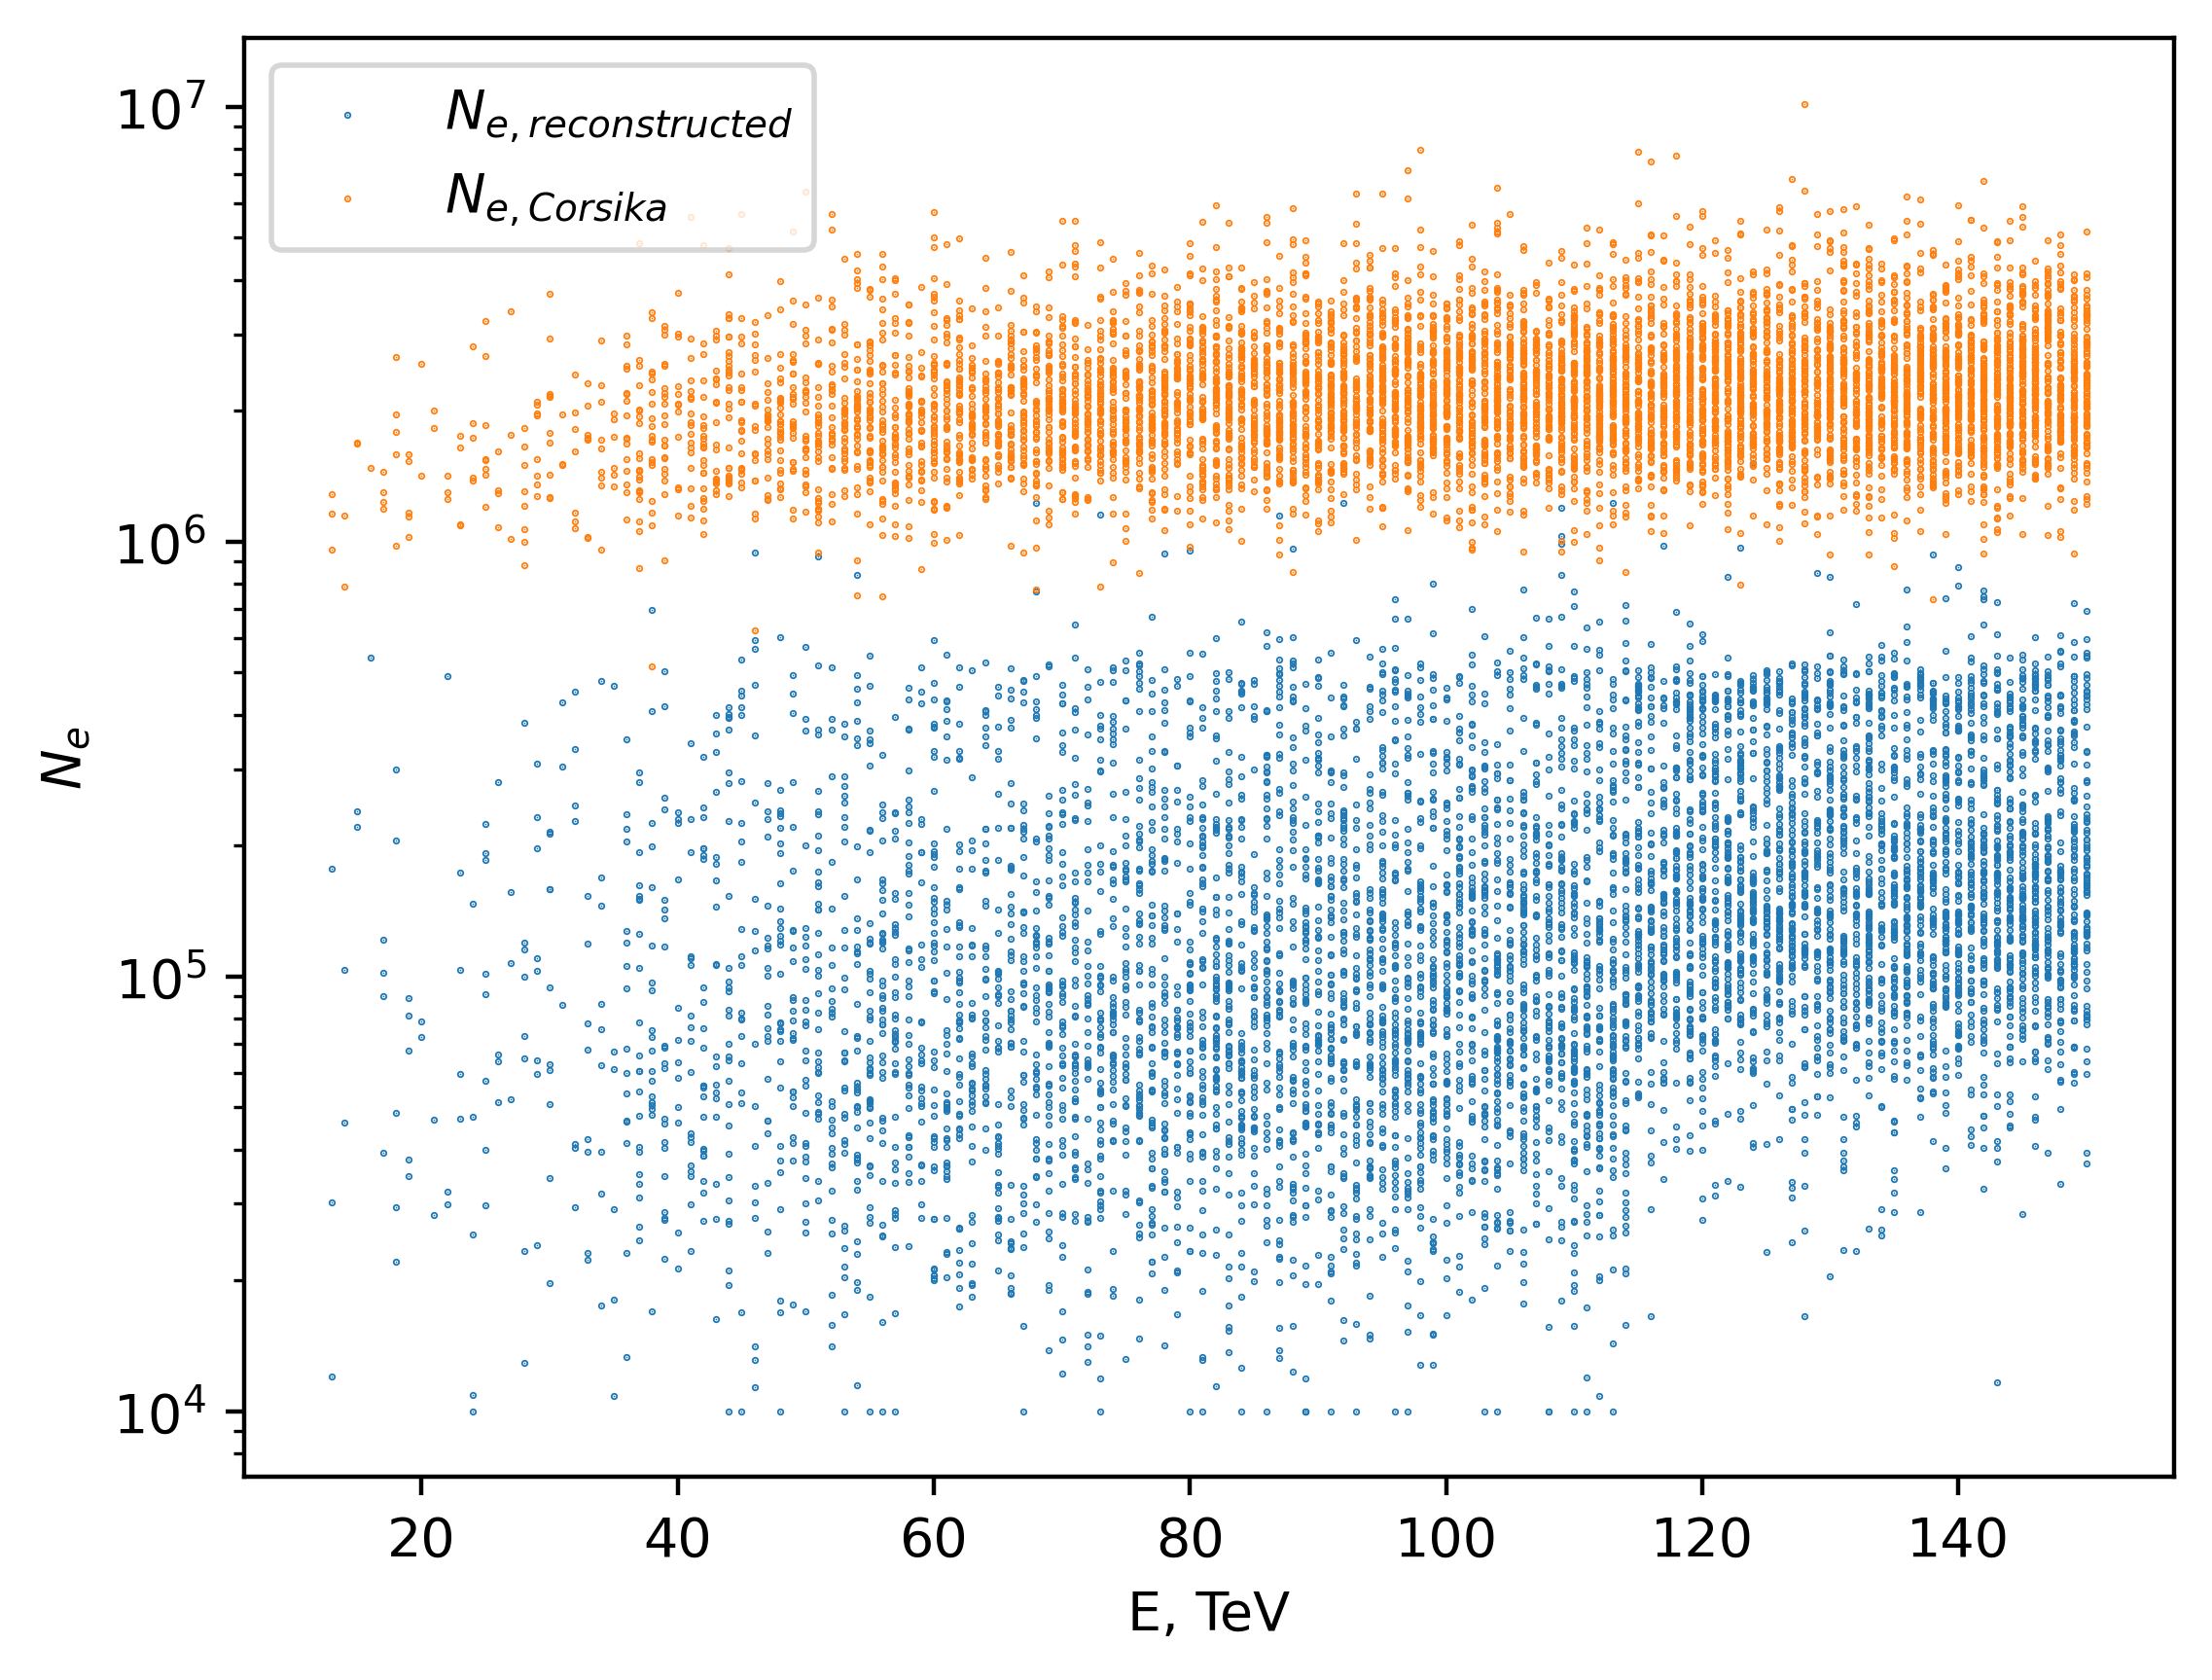

In [5]:
plt.scatter(E, Ne, s=0.1, label='$N_{e,reconstructed}$')
plt.scatter(E, Ne_true, s=0.1, label='$N_{e,Corsika}$')

plt.xlabel('E, TeV')
plt.ylabel('$N_{e}$')

plt.legend()

plt.yscale('log')
plt.savefig('Ne(E).png')

In [6]:
# plt.hist2d(E, Ne_true, s=0.1)

# plt.xlabel('E, TeV')
# plt.ylabel('$N_{e,true}$')

# plt.yscale('log')
# plt.savefig('Ne(E)_true.png')

In [7]:
np.savetxt('Ne.txt', np.array([E, Ne, Ne_true]), header='E, TeV; Ne, Ne_true', fmt='%i')